Dataset Source: https://www.kaggle.com/c/boston-housing

Description

Housing Values in Suburbs of Boston

The medv variable is the target variable.

Data description
The Boston data frame has 506 rows and 14 columns.
This data frame contains the following columns:

crim - per capita crime rate by town.
zn - proportion of residential land zoned for lots over 25,000 sq.ft.
indus - proportion of non-retail business acres per town.
chas - Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).
nox - nitrogen oxides concentration (parts per 10 million).
rm - average number of rooms per dwelling.
age - proportion of owner-occupied units built prior to 1940.
dis - weighted mean of distances to five Boston employment centres.
rad - index of accessibility to radial highways.
tax - full-value property-tax rate per \$10,000.
ptratio - pupil-teacher ratio by town.
black - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town.
lstat - lower status of the population (percent).
medv - median value of owner-occupied homes in \$1000s.

Source
Harrison, D. and Rubinfeld, D.L. (1978) Hedonic prices and the demand for clean air. J. Environ. Economics and Management 5, 81–102.
Belsley D.A., Kuh, E. and Welsch, R.E. (1980) Regression Diagnostics. Identifying Influential Data and Sources of Collinearity. New York: Wiley.

In [1]:
import pandas as pd

# Store the raw GitHub URL in a variable
url = 'https://raw.githubusercontent.com/Faweenagua/ML-Regression-Projects/refs/heads/master/Housing%20Price%20Prediction/boston_data.csv'

# Use pandas to read the CSV file directly from the URL
df = pd.read_csv(url)


# Display the first few rows of the DataFrame to verify
print(df.head())


   ID  indus  chas    nox     rm   age     dis  rad  tax  ptratio  lstat  medv
0   1   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   4.98  24.0
1   2   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   9.14  21.6
2   4   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   2.94  33.4
3   5   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   5.33  36.2
4   7   7.87     0  0.524  6.012  66.6  5.5605    5  311     15.2  12.43  22.9


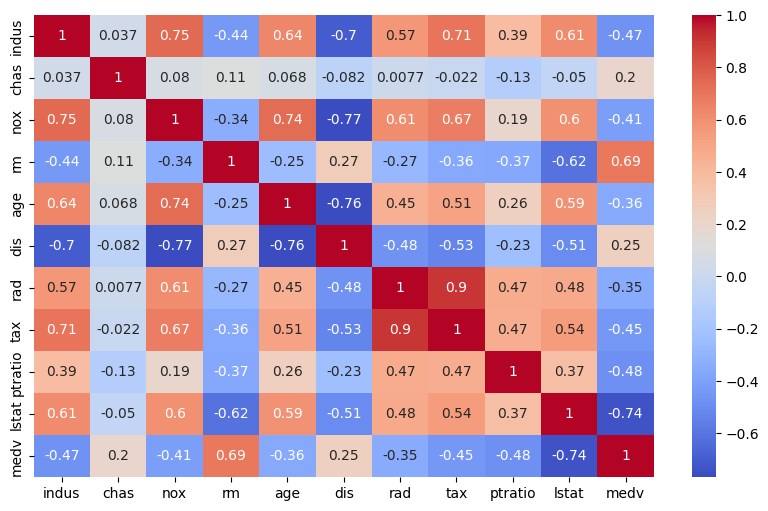

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pairplot to visualize relationships between variables
df = df.drop(columns=['ID'])  # Drop unnecessary column if present
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

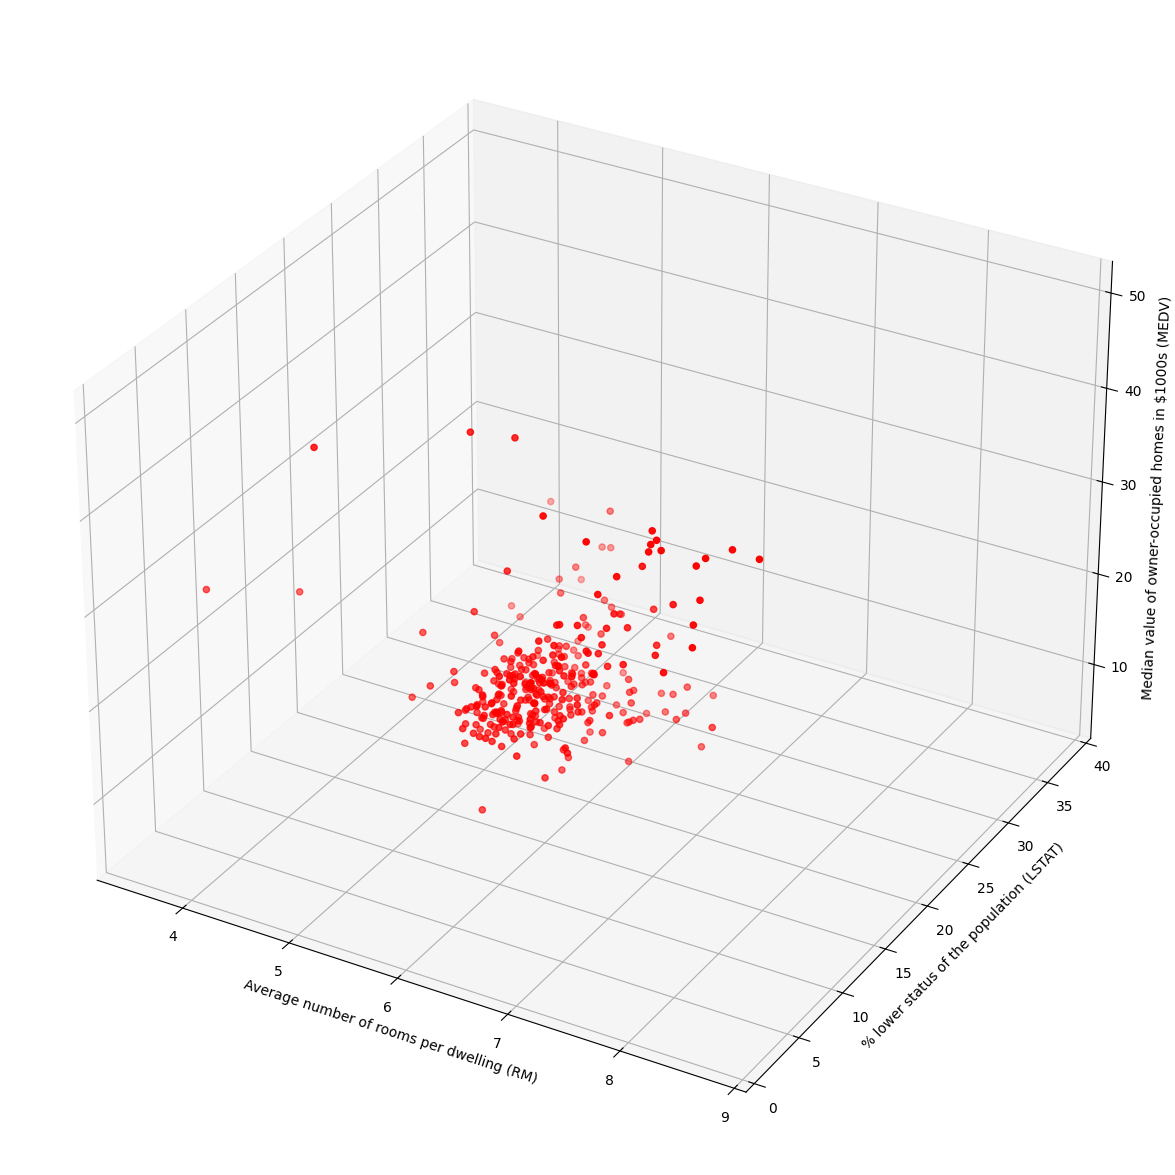

In [3]:
# Import the mplot3d toolkit (necessary for 3D projection)
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['rm'], df['lstat'], df['medv'], c='r', marker='o')
ax.set_xlabel('Average number of rooms per dwelling (RM)')
ax.set_ylabel('% lower status of the population (LSTAT)')
ax.set_zlabel('Median value of owner-occupied homes in $1000s (MEDV)')
plt.show()

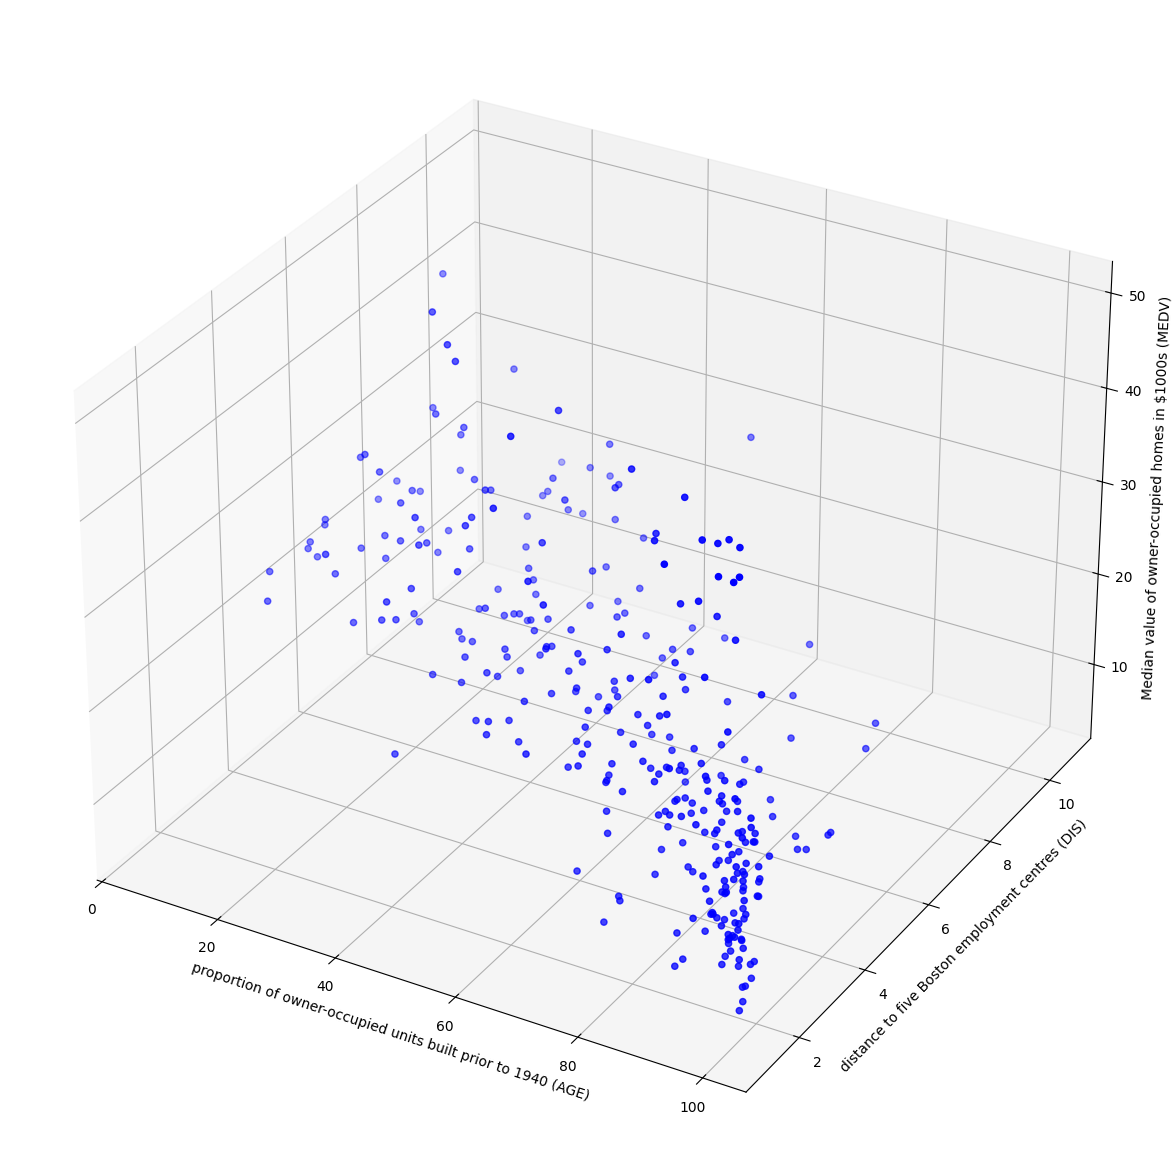

In [4]:
# Import the mplot3d toolkit (necessary for 3D projection)
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['age'], df['dis'], df['medv'], c='b', marker='o')
ax.set_xlabel('proportion of owner-occupied units built prior to 1940 (AGE)')
ax.set_ylabel('distance to five Boston employment centres (DIS)')
ax.set_zlabel('Median value of owner-occupied homes in $1000s (MEDV)')
plt.show()

In [5]:
x = df.drop('medv', axis=1)
y = df['medv']
x['ones'] = 1  # Add a column of ones to account for the intercept term
x.head()

,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,ones
0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,1
1,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,1
2,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,1
3,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,1
4,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,12.43,1


In [6]:
y.head()

,medv
0,24.0
1,21.6
2,33.4
3,36.2
4,22.9


In [7]:
from sklearn.model_selection import train_test_split
import numpy as np

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [8]:
x_train.head()

,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,ones
224,5.19,0,0.515,5.985,45.4,4.8122,5,224,20.2,9.74,1
78,10.01,0,0.547,6.021,82.6,2.7474,6,432,17.8,10.30,1
295,18.10,0,0.713,6.525,86.5,2.4358,24,666,20.2,18.13,1
17,8.14,0,0.538,6.047,88.8,4.4534,4,307,21.0,17.28,1
24,6.91,0,0.448,6.169,6.6,5.7209,3,233,17.9,5.81,1


In [9]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((266, 11), (67, 11), (266,), (67,))

In [10]:
W = x_train.to_numpy()
T = y_train.to_numpy().reshape(-1, 1)
W.shape, T.shape

((266, 11), (266, 1))

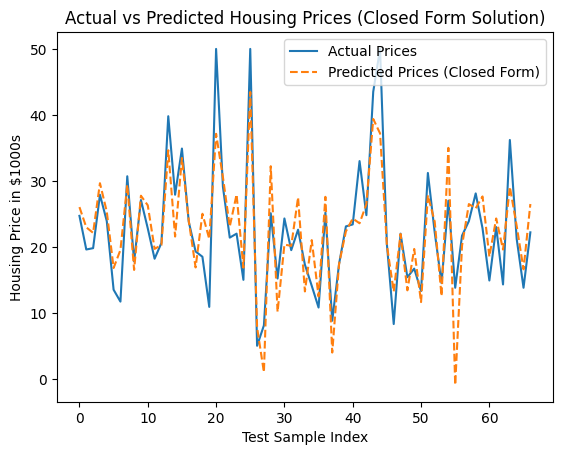

In [11]:
## Implementing Linear Regression using Closed Form Solution

Theta_star_closed_form = np.linalg.inv(W.T @ W) @ W.T @ T
Theta_star_closed_form.shape
y_pred_closed_form = x_test.to_numpy() @ Theta_star_closed_form
y_pred_closed_form

plt.plot(y_test.to_numpy(), label='Actual Prices')
plt.plot(y_pred_closed_form, label='Predicted Prices (Closed Form)', linestyle='--')
plt.xlabel('Test Sample Index')
plt.ylabel('Housing Price in $1000s')
plt.title('Actual vs Predicted Housing Prices (Closed Form Solution)')
plt.legend()
plt.show()


In [12]:
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred_closed_form)
mse = mean_squared_error(y_test, y_pred_closed_form)

print(f"The calculated RMSE is: {rmse}")
print(f"The calculated MSE is: {mse}")


The calculated RMSE is: 4.937002228570318
The calculated MSE is: 24.373991004908284


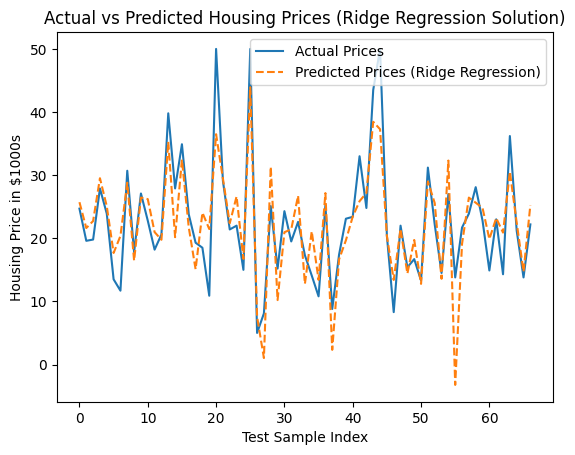

In [106]:
## Implementing Linear Regression using Ridge Regression
lambda_param = 0.9  # Regularization parameter
I = np.eye(W.shape[1])
Theta_star_ridge = np.linalg.inv(W.T @ W + lambda_param * I) @ W.T @ T
# Theta_star_ridge.shape
y_pred_ridge = x_test.to_numpy() @ Theta_star_ridge

plt.plot(y_test.to_numpy(), label='Actual Prices')
plt.plot(y_pred_ridge, label='Predicted Prices (Ridge Regression)', linestyle='--')
plt.xlabel('Test Sample Index')
plt.ylabel('Housing Price in $1000s')
plt.title('Actual vs Predicted Housing Prices (Ridge Regression Solution)')
plt.legend()
plt.show()

In [14]:
Theta_star_ridge.shape

(11, 1)

In [15]:
rmse = root_mean_squared_error(y_test, y_pred_ridge)
mse = mean_squared_error(y_test, y_pred_ridge)

print(f"The calculated RMSE is: {rmse}")
print(f"The calculated MSE is: {mse}")

The calculated RMSE is: 4.991677590795634
The calculated MSE is: 24.916845170451303


In [16]:
len(T)

266

In [17]:
## Implementing Linear Regression using Gradient Descent
def gradient_descent(X, y, learning_rate=0.01, n_iterations=1000):
    m, n = X.shape
    Theta = np.zeros((n, 1))
    
    for _ in range(n_iterations):
        gradients = (2/m) * X.T @ (X @ Theta - y)
        Theta -= learning_rate * gradients
        
    return Theta 

Theta_star_GD = gradient_descent(W, T, learning_rate=0.000001, n_iterations=1000)

In [115]:
## Implementing Linear Regression using Gradient Descent
learning_rate = 0.0000008
lambda_param = 0.05
n_iterations = 1000

Theta_star_GD = np.ones((W.shape[1], 1))  # Initialize weights
for iteration in range(n_iterations):
    pred = W @ Theta_star_GD
    error = pred - T
    grad = (2 / W.shape[0]) * (W.T @ error)
    Theta_star_GD -= learning_rate * grad

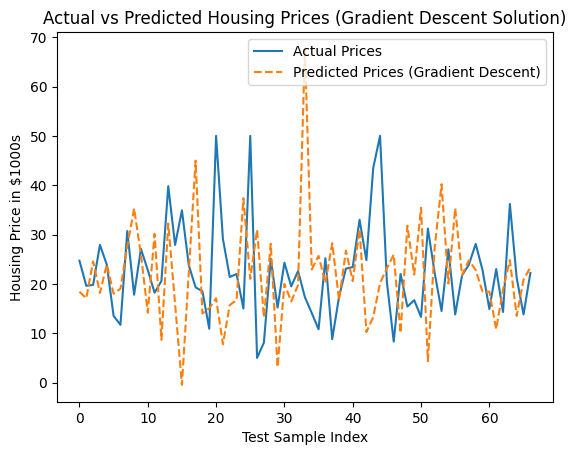

In [116]:
y_pred_GD = x_test.to_numpy() @ Theta_star_GD

plt.plot(y_test.to_numpy(), label='Actual Prices')
plt.plot(y_pred_GD, label='Predicted Prices (Gradient Descent)', linestyle='--')
plt.xlabel('Test Sample Index')
plt.ylabel('Housing Price in $1000s')
plt.title('Actual vs Predicted Housing Prices (Gradient Descent Solution)')
plt.legend()
plt.show()

In [20]:
y_test

,medv
25,24.7
309,19.6
73,19.8
195,27.9
57,23.9
...,...
280,14.3
3,36.2
77,21.2
311,13.8


In [21]:
y_pred_GD

array([[25.1826951 ],
       [20.35272855],
       [16.93046091],
       [22.34529352],
       [22.28597166],
       [22.89766076],
       [21.01290722],
       [17.7786725 ],
       [26.49545298],
       [24.71742012],
       [11.84669637],
       [22.57776897],
       [22.3317223 ],
       [21.28236719],
       [17.20562703],
       [ 6.3566713 ],
       [18.0498865 ],
       [33.04645572],
       [11.05997657],
       [20.6075231 ],
       [11.95896733],
       [14.02739061],
       [19.4691058 ],
       [19.63239478],
       [26.31492396],
       [15.03867665],
       [29.60725815],
       [14.02800565],
       [22.36934479],
       [ 6.78808312],
       [24.29902016],
       [21.1981742 ],
       [15.3119473 ],
       [48.8406088 ],
       [24.41514977],
       [26.04377731],
       [24.52980098],
       [28.72217306],
       [20.67302427],
       [17.40596146],
       [24.48443525],
       [26.37918733],
       [20.93952873],
       [12.0568669 ],
       [13.65276813],
       [17

In [22]:
rmse = root_mean_squared_error(y_test, y_pred_GD)
mse = mean_squared_error(y_test, y_pred_GD)

print(f"The calculated RMSE is: {rmse}")
print(f"The calculated MSE is: {mse}")

The calculated RMSE is: 13.677499051310612
The calculated MSE is: 187.07398029860266


In [101]:
## Implementing Linear Regression using Stochastic Gradient Descent
learning_rate = 0.00002
lambda_param = 1
n_iterations = 1000

m, n = W.shape

i = np.random.randint(0, n, n_iterations)


Theta_star_SGD = np.zeros((n, 1))  # Initialize weights
for iterationmm in range(n_iterations):
    for iteration in range(m):
        pred = Theta_star_SGD.T @ W[i[iteration]]  
        error = pred - T[i[iteration]]
        grad = (2 / n) * W[i[iteration]].reshape(-1, 1) * error
        Theta_star_SGD -= learning_rate * grad

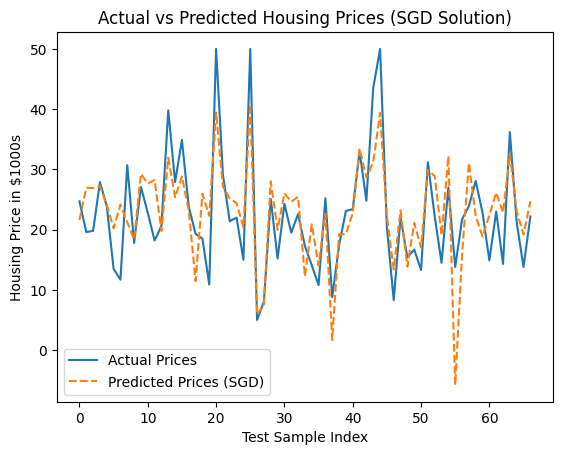

In [102]:
y_pred_SGD = x_test.to_numpy() @ Theta_star_SGD

plt.plot(y_test.to_numpy(), label='Actual Prices')
plt.plot(y_pred_SGD, label='Predicted Prices (SGD)', linestyle='--')
plt.xlabel('Test Sample Index')
plt.ylabel('Housing Price in $1000s')
plt.title('Actual vs Predicted Housing Prices (SGD Solution)')
plt.legend()
plt.show()

In [103]:
rmse = root_mean_squared_error(y_test, y_pred_SGD)
mse = mean_squared_error(y_test, y_pred_SGD)

print(f"The calculated RMSE is: {rmse}")
print(f"The calculated MSE is: {mse}")

The calculated RMSE is: 6.126876744660046
The calculated MSE is: 37.538618644256076


In [ ]:
## Implementing Linear Regression using Stochastic Gradient Descent
def stochastic_gradient_descent(X, y, learning_rate=0.01, n_iterations=1000):
    m, n = X.shape
    Theta = np.zeros((n, 1))
    
    for _ in range(n_iterations):
        for i in range(m):
            xi = X[i, :].reshape(1, -1)
            yi = y[i]
            gradients = 2 * xi.T @ (xi @ Theta - yi)
            Theta -= learning_rate * gradients
            
    return Theta

SGD Linear Regression RMSE: 6.4541


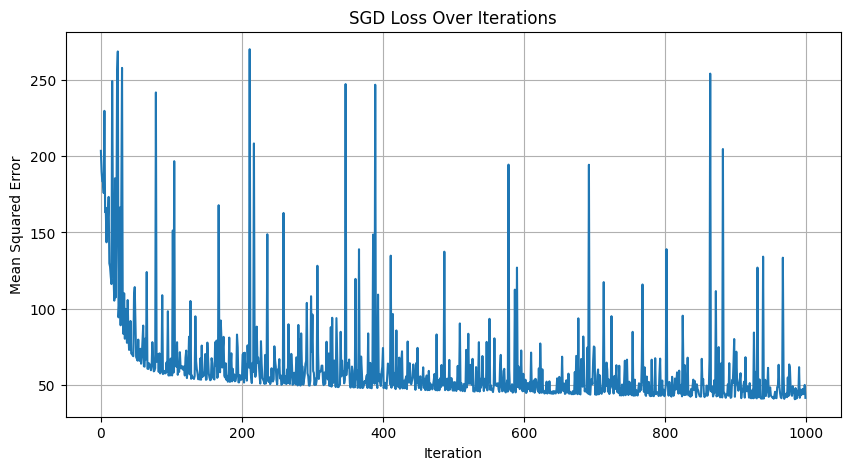

In [42]:
## Stochastic Gradient Descent for Linear Regression - Complete Implementation

class SGDLinearRegression:
    """
    Stochastic Gradient Descent for Linear Regression
    """
    def __init__(self, learning_rate=0.000001, n_iterations=1000, batch_size=1, random_state=None):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.batch_size = batch_size
        self.random_state = random_state
        self.theta = None
        self.loss_history = []
        
    def fit(self, X, y):
        """
        Fit the model using SGD
        
        Parameters:
        X : array-like (m, n) - m samples, n features
        y : array-like (m,) - target values
        """
        m, n = X.shape
        self.theta = np.zeros((n, 1))
        
        if self.random_state:
            np.random.seed(self.random_state)
        
        for iteration in range(self.n_iterations):
            # Shuffle indices
            indices = np.random.permutation(m)
            
            # Iterate through batches
            for i in range(0, m, self.batch_size):
                batch_indices = indices[i:i + self.batch_size]
                X_batch = X[batch_indices].reshape(-1, n)
                y_batch = y[batch_indices].reshape(-1, 1)
                
                # Predictions
                y_pred = X_batch @ self.theta
                
                # Compute error
                errors = y_pred - y_batch
                
                # Gradient: (2/m) * X^T * (y_pred - y)
                gradient = (2 / len(batch_indices)) * (X_batch.T @ errors)
                
                # Update weights with learning rate decay
                self.theta -= self.learning_rate * gradient
            
            # Calculate loss for tracking
            y_pred_full = X @ self.theta
            mse = np.mean((y_pred_full - y.reshape(-1, 1)) ** 2)
            self.loss_history.append(mse)
        
        return self
    
    def predict(self, X):
        """
        Make predictions
        
        Parameters:
        X : array-like (m, n)
        
        Returns:
        predictions : array (m,)
        """
        return (X @ self.theta).flatten()
    
    def get_theta(self):
        """
        Get the learned weights
        
        Returns:
        theta : array (n, 1)
        """
        return self.theta

# Example usage with the housing data:
# Initialize model
sgd_model = SGDLinearRegression(learning_rate=0.000001, n_iterations=1000, batch_size=1, random_state=42)

# Fit the model (using W and T from your data)
sgd_model.fit(W, T.flatten())

# Make predictions
y_pred_sgd = sgd_model.predict(W)

# Calculate RMSE
rmse_sgd = np.sqrt(np.mean((y_pred_sgd - T.flatten()) ** 2))
print(f"SGD Linear Regression RMSE: {rmse_sgd:.4f}")

# Plot loss history
plt.figure(figsize=(10, 5))
plt.plot(sgd_model.loss_history)
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.title('SGD Loss Over Iterations')
plt.grid(True)
plt.show()

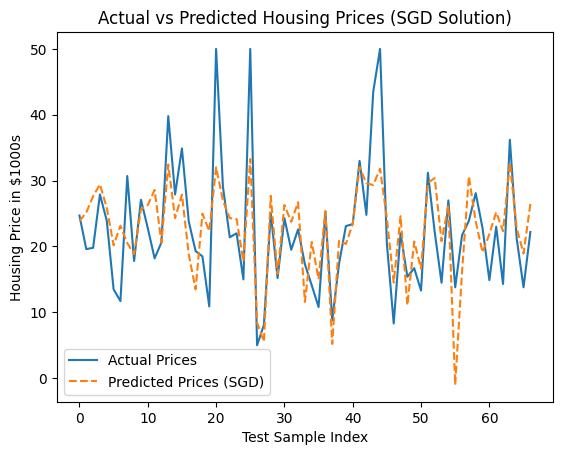

In [43]:
y_pred_SGD = x_test.to_numpy() @ sgd_model.get_theta()

plt.plot(y_test.to_numpy(), label='Actual Prices')
plt.plot(y_pred_SGD, label='Predicted Prices (SGD)', linestyle='--')
plt.xlabel('Test Sample Index')
plt.ylabel('Housing Price in $1000s')
plt.title('Actual vs Predicted Housing Prices (SGD Solution)')
plt.legend()
plt.show()